# 实验：Mediano 线性高斯基准

目标：
- 在线性高斯 AR(1) 设定下复用六个八节点的 Mediano 风格拓扑。
- 将基于机制的 `EI_full` 和 `Syn_high` 与 Mediano et al. (2018) 指标的一个首轮子集进行比较：`Phi`、`Phi_tilde`、`psi`、`CD`，以及 `TDMI` 和平均绝对相关。
- 为了进行类似论文图 5 风格的比较，使用接近论文设定的默认动力学：谱半径 `0.9`、单位噪声协方差以及零噪声相关。
- 对 EI 本身，则从高斯代理干预切换为有限均匀盒式干预近似，盒宽 `L` 根据基准状态尺度来选取。
- 需要注意，网络 `B` 和 `C` 目前仍是代理性重建，而不是原始研究中精确优化得到的矩阵。


In [1]:
from __future__ import annotations

import html
import math
import sys
from pathlib import Path
from typing import Any

import numpy as np

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'utils.py').exists():
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)
        break

from utils import (
    linear_gaussian_mediano_metrics,
    linear_gaussian_uniform_box_ei_decomposition,
    render_matrix_heatmap_svg,
    render_topology_mechanism_svg,
    solve_stationary_covariance,
)

try:
    from IPython.display import HTML, SVG, display
except Exception:  # pragma: no cover - notebook fallback
    HTML = SVG = None
    display = print


In [2]:
N_NODES = 8
TARGET_SPECTRAL_RADIUS = 0.9
SELF_WEIGHT = 0.0
NOISE_VARIANCE = 1.0
NOISE_CORRELATION = 0.0
UNIFORM_BOX_SIGMA_MULTIPLIER = 6.0

def fully_connected() -> np.ndarray:
    return np.ones((N_NODES, N_NODES), dtype=float) - np.eye(N_NODES)

def bidirectional_ring() -> np.ndarray:
    adjacency = np.zeros((N_NODES, N_NODES), dtype=float)
    for i in range(N_NODES):
        adjacency[(i - 1) % N_NODES, i] = 1.0
        adjacency[(i + 1) % N_NODES, i] = 1.0
    return adjacency

def unidirectional_ring() -> np.ndarray:
    adjacency = np.zeros((N_NODES, N_NODES), dtype=float)
    for i in range(N_NODES):
        adjacency[(i - 1) % N_NODES, i] = 1.0
    return adjacency

def small_world() -> np.ndarray:
    adjacency = bidirectional_ring()
    adjacency[0, 4] = 1.0
    adjacency[4, 0] = 1.0
    return adjacency

def phi_optimal_binary_like() -> np.ndarray:
    adjacency = np.zeros((N_NODES, N_NODES), dtype=float)
    edges = [
        (0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4),
        (4, 6), (5, 7), (6, 0), (7, 2), (6, 3), (2, 6),
    ]
    for src, dst in edges:
        adjacency[src, dst] = 1.0
    return adjacency

def phi_optimal_weighted_like() -> np.ndarray:
    adjacency = np.zeros((N_NODES, N_NODES), dtype=float)
    weights = {
        (0, 1): 1.2,
        (0, 3): 0.9,
        (1, 2): 1.1,
        (1, 4): 0.8,
        (2, 5): 1.4,
        (3, 4): 1.0,
        (4, 6): 1.3,
        (5, 7): 1.1,
        (6, 0): 0.7,
        (7, 2): 1.2,
        (6, 3): 1.5,
        (2, 6): 1.0,
    }
    for (src, dst), weight in weights.items():
        adjacency[src, dst] = weight
    return adjacency

TOPOLOGIES = {
    'A': fully_connected(),
    'B': phi_optimal_binary_like(),
    'C': phi_optimal_weighted_like(),
    'D': bidirectional_ring(),
    'E': small_world(),
    'F': unidirectional_ring(),
}

TOPOLOGY_LABELS = {
    'A': 'fully connected',
    'B': 'binary-like optimal',
    'C': 'weighted-like optimal',
    'D': 'bidirectional ring',
    'E': 'small world',
    'F': 'unidirectional ring',
}


## 动力学设定与比较范围
每个拓扑都嵌入到同一个线性高斯 AR(1) 族中：$X_{t+1} = A X_t + \epsilon_t$。默认情况下，这份文档在动力学设定上更贴近原论文：每个邻接矩阵都会被缩放到谱半径 `0.9`，噪声协方差取单位矩阵（`c = 0`）。

但对于 EI 本身，我们现在切换到框架中讨论的有界状态视角：干预被建模为施加在所选源坐标上的均匀盒分布，并使用相应的高信噪比伪行列式近似来评估线性高斯 EI。盒宽 `L` 不再任意固定，而是由基准状态尺度决定：在计算六个基准网络的平稳协方差之后，我们设定 `L = 6 * max(std)`，使得方差最大的变量大致被覆盖在 `±3σ` 范围内。

这份文档比较两组量：
- 来自 EI 分解框架的机制型量：`EI_full`、`UnBudget`、`Syn_high`、`rho_high`。
- 受 Mediano et al. (2018) 启发的自发分布型量：`Phi`、`Phi_tilde`、`psi`、`CD`、`TDMI` 以及平均绝对相关。

在这种均匀盒近似下，如果所选的 `L` 还不足以压过噪声和退化效应，那么 `EI_full` 本身可能会变成负值，因此更稳定、也更值得关注的对象通常是差值结构（`Syn_high` 及其对应排序），而不是 EI 的绝对大小。

一个重要的复现实验说明：`B` 和 `C` 仍然只是原始优化网络的近似替代，因此即便使用相同的谱半径与噪声设定，也不应期待与论文数值完全一致。对于拓扑 `E`，当前重建使用了两条构成互惠对的有向远程连接；此前不带箭头的绘制方式会把它们压缩成一条看起来像无向边的弦。


In [3]:
def neutral_node_specs() -> list[dict[str, Any]]:
    return [
        {
            'bias': 0.0,
            'alpha': 0.0,
            'beta': 0.0,
            'gamma': 0.0,
            'coop_pairs': [],
            'parity_sources': [],
        }
        for _ in range(N_NODES)
    ]

def spectral_radius(matrix: np.ndarray) -> float:
    return float(max(abs(value) for value in np.linalg.eigvals(matrix)))

def build_coupling(adjacency: np.ndarray) -> np.ndarray:
    base = np.asarray(adjacency, dtype=float) + SELF_WEIGHT * np.eye(N_NODES)
    radius = spectral_radius(base)
    if radius <= 1e-12:
        return base.copy()
    return base * (TARGET_SPECTRAL_RADIUS / radius)

def build_noise_covariance() -> np.ndarray:
    return NOISE_VARIANCE * ((1.0 - NOISE_CORRELATION) * np.eye(N_NODES) + NOISE_CORRELATION * np.ones((N_NODES, N_NODES)))

def display_topology_panels() -> None:
    blocks = []
    for name, adjacency in TOPOLOGIES.items():
        svg = render_topology_mechanism_svg(name, TOPOLOGY_LABELS[name], adjacency, neutral_node_specs())
        blocks.append(
            "<div style='display:inline-block;vertical-align:top;margin:10px 12px 18px 0;'>"
            + svg
            + "</div>"
        )
    if HTML is not None:
        display(HTML(''.join(blocks)))
    else:
        print('\n\n'.join(blocks))

def render_bar_chart(title: str, values: dict[str, float], color: str = '#4C78A8') -> None:
    width = 660
    height = 260
    margin_left = 60
    margin_bottom = 40
    margin_top = 28
    chart_width = width - margin_left - 20
    chart_height = height - margin_top - margin_bottom
    if not values:
        return
    min_value = min(min(values.values()), 0.0)
    max_value = max(max(values.values()), 0.0)
    span = max(max_value - min_value, 1e-9)
    baseline_y = margin_top + chart_height * (max_value / span)
    bar_width = chart_width / len(values)
    pieces = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}'>",
        f"<text x='{width/2}' y='18' text-anchor='middle' font-size='15'>{html.escape(title)}</text>",
        f"<line x1='{margin_left}' y1='{baseline_y:.1f}' x2='{width-15}' y2='{baseline_y:.1f}' stroke='black'/>",
        f"<line x1='{margin_left}' y1='{margin_top}' x2='{margin_left}' y2='{margin_top + chart_height}' stroke='black'/>",
    ]
    for idx, (label, value) in enumerate(values.items()):
        scaled = chart_height * (abs(value) / span)
        x = margin_left + idx * bar_width + 8
        y = baseline_y - scaled if value >= 0 else baseline_y
        pieces.append(
            f"<rect x='{x:.1f}' y='{y:.1f}' width='{bar_width - 16:.1f}' height='{scaled:.1f}' fill='{color}' opacity='0.85'/>"
        )
        pieces.append(
            f"<text x='{x + (bar_width - 16)/2:.1f}' y='{margin_top + chart_height + 18}' text-anchor='middle' font-size='12'>{html.escape(label)}</text>"
        )
        value_y = y - 6 if value >= 0 else y + scaled + 14
        pieces.append(
            f"<text x='{x + (bar_width - 16)/2:.1f}' y='{value_y:.1f}' text-anchor='middle' font-size='10.5'>{value:.3f}</text>"
        )
    pieces.append('</svg>')
    svg_text = ''.join(pieces)
    if SVG is not None:
        display(SVG(svg_text))
    else:
        print(title, values)


## 拓扑面板

In [4]:
display_topology_panels()

noise_covariance = build_noise_covariance()
structure_rows = []
for name, adjacency in TOPOLOGIES.items():
    coupling = build_coupling(adjacency)
    state_cov = solve_stationary_covariance(coupling, noise_covariance)
    edge_count = int(np.count_nonzero(adjacency))
    density = edge_count / (N_NODES * (N_NODES - 1))
    structure_rows.append((name, TOPOLOGY_LABELS[name], edge_count, round(density, 3), round(spectral_radius(coupling), 3), round(float(np.trace(state_cov)), 3)))
structure_rows


[('A', 'fully connected', 56, 1.0, 0.9, 12.381),
 ('B', 'binary-like optimal', 12, 0.214, 0.9, 22.249),
 ('C', 'weighted-like optimal', 12, 0.214, 0.9, 23.829),
 ('D', 'bidirectional ring', 16, 0.286, 0.9, 19.249),
 ('E', 'small world', 18, 0.321, 0.9, 15.691),
 ('F', 'unidirectional ring', 8, 0.143, 0.9, 42.105)]

## 计算 EI 分解与 Mediano 风格指标

In [5]:
noise_covariance = build_noise_covariance()
precomputed = {}
max_stationary_std = 0.0
for name, adjacency in TOPOLOGIES.items():
    coupling = build_coupling(adjacency)
    state_covariance = solve_stationary_covariance(coupling, noise_covariance)
    precomputed[name] = (coupling, state_covariance)
    max_stationary_std = max(max_stationary_std, float(np.sqrt(np.diag(state_covariance)).max()))

UNIFORM_BOX_SIZE = UNIFORM_BOX_SIGMA_MULTIPLIER * max_stationary_std

results = {}
for name, adjacency in TOPOLOGIES.items():
    coupling, state_covariance = precomputed[name]
    ei_summary = linear_gaussian_uniform_box_ei_decomposition(
        coupling,
        noise_covariance,
        box_size=UNIFORM_BOX_SIZE,
        log_base=np.e,
    )
    metric_summary = linear_gaussian_mediano_metrics(
        coupling,
        noise_covariance,
        log_base=np.e,
    )
    edge_count = int(np.count_nonzero(adjacency))
    density = edge_count / (N_NODES * (N_NODES - 1))
    results[name] = {
        'label': TOPOLOGY_LABELS[name],
        'edge_count': edge_count,
        'density': density,
        'spectral_radius': spectral_radius(coupling),
        'coupling': coupling,
        'state_covariance': state_covariance,
        'uniform_box_size': UNIFORM_BOX_SIZE,
        **ei_summary,
        **metric_summary,
    }

results


{'A': {'label': 'fully connected',
  'edge_count': 56,
  'density': 1.0,
  'spectral_radius': 0.9000000000000002,
  'coupling': array([[0.        , 0.12857143, 0.12857143, 0.12857143, 0.12857143,
          0.12857143, 0.12857143, 0.12857143],
         [0.12857143, 0.        , 0.12857143, 0.12857143, 0.12857143,
          0.12857143, 0.12857143, 0.12857143],
         [0.12857143, 0.12857143, 0.        , 0.12857143, 0.12857143,
          0.12857143, 0.12857143, 0.12857143],
         [0.12857143, 0.12857143, 0.12857143, 0.        , 0.12857143,
          0.12857143, 0.12857143, 0.12857143],
         [0.12857143, 0.12857143, 0.12857143, 0.12857143, 0.        ,
          0.12857143, 0.12857143, 0.12857143],
         [0.12857143, 0.12857143, 0.12857143, 0.12857143, 0.12857143,
          0.        , 0.12857143, 0.12857143],
         [0.12857143, 0.12857143, 0.12857143, 0.12857143, 0.12857143,
          0.12857143, 0.        , 0.12857143],
         [0.12857143, 0.12857143, 0.12857143, 0.1285714

In [6]:
ranking = sorted(
    results.items(),
    key=lambda item: (item[1]['syn_high'], item[1]['ei_full']),
    reverse=True,
)

if HTML is not None:
    note = (
        f"<p><strong>Uniform intervention box:</strong> L = {UNIFORM_BOX_SIZE:.3f}. "
        f"This equals {UNIFORM_BOX_SIGMA_MULTIPLIER:.1f} times the largest stationary standard deviation across the six benchmark networks.</p>"
    )
    rows = [
        '<tr><th>Rank</th><th>Network</th><th>Label</th><th>EI_full</th><th>Syn_high</th><th>Phi</th><th>Phi_tilde</th><th>psi</th><th>CD</th><th>TDMI</th></tr>'
    ]
    for idx, (name, row) in enumerate(ranking, start=1):
        rows.append(
            '<tr>'
            f'<td>{idx}</td>'
            f'<td>{name}</td>'
            f"<td>{html.escape(row['label'])}</td>"
            f"<td>{row['ei_full']:.3f}</td>"
            f"<td>{row['syn_high']:.3f}</td>"
            f"<td>{row['phi']:.3f}</td>"
            f"<td>{row['phi_tilde']:.3f}</td>"
            f"<td>{row['psi']:.3f}</td>"
            f"<td>{row['causal_density']:.3f}</td>"
            f"<td>{row['tdmi']:.3f}</td>"
            '</tr>'
        )
    display(HTML(note + "<table style='border-collapse:collapse' border='1'>" + ''.join(rows) + '</table>'))
else:
    print('Uniform intervention box size L =', UNIFORM_BOX_SIZE)
    for idx, (name, row) in enumerate(ranking, start=1):
        print(idx, name, row)


Rank,Network,Label,EI_full,Syn_high,Phi,Phi_tilde,psi,CD,TDMI
1,B,binary-like optimal,0.176,0.002,0.612,0.963,1.131,0.058,3.217
2,C,weighted-like optimal,0.193,0.002,0.571,0.917,1.157,0.062,3.451
3,D,bidirectional ring,0.132,0.001,0.275,0.651,1.038,0.042,2.699
4,A,fully connected,0.037,0.001,0.067,0.372,0.292,0.009,0.889
5,E,small world,0.108,0.001,0.324,0.643,0.699,0.033,2.055
6,F,unidirectional ring,0.261,0.000,1.661,1.661,3.321,0.119,6.643


## 指标画像

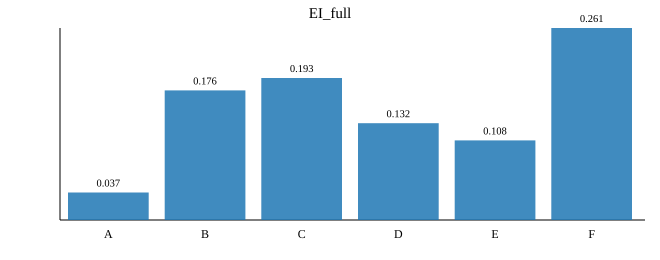

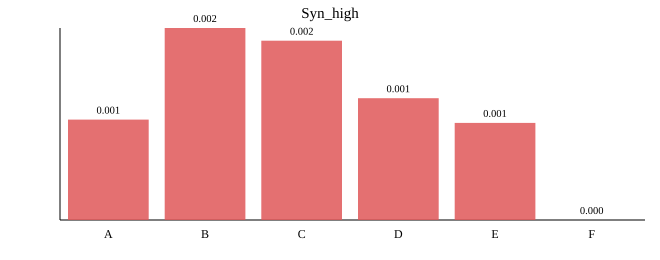

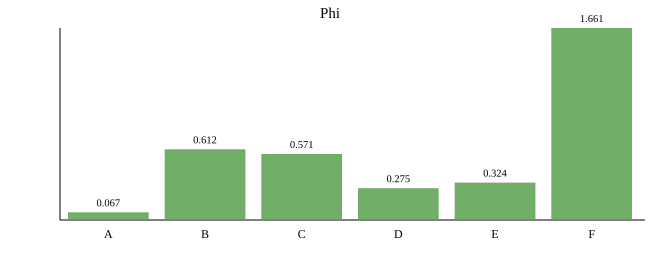

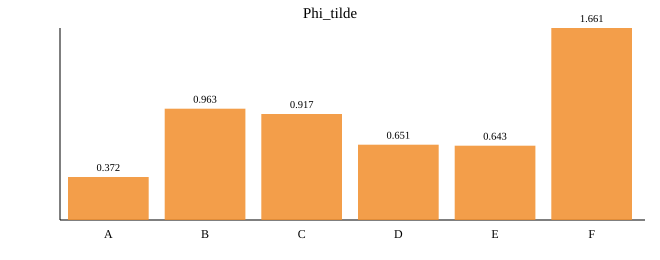

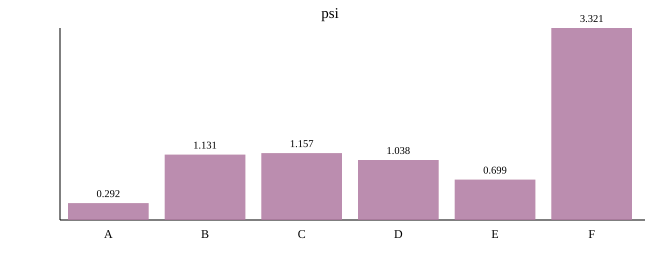

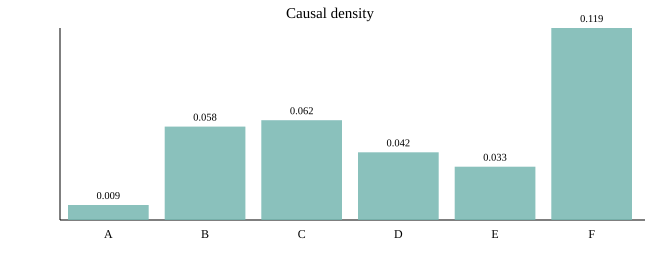

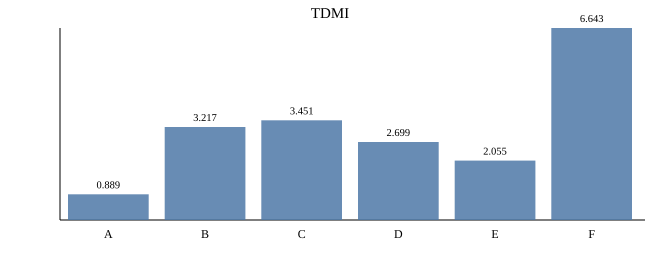

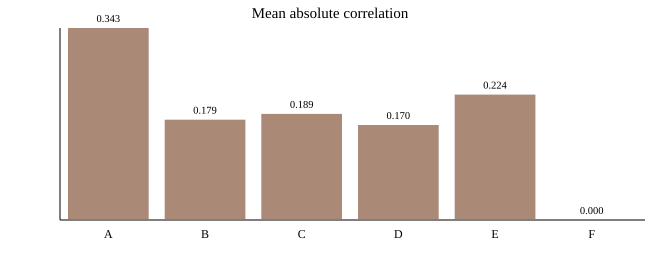

In [7]:
render_bar_chart('EI_full', {k: v['ei_full'] for k, v in results.items()}, color='#1F77B4')
render_bar_chart('Syn_high', {k: v['syn_high'] for k, v in results.items()}, color='#E15759')
render_bar_chart('Phi', {k: v['phi'] for k, v in results.items()}, color='#59A14F')
render_bar_chart('Phi_tilde', {k: v['phi_tilde'] for k, v in results.items()}, color='#F28E2B')
render_bar_chart('psi', {k: v['psi'] for k, v in results.items()}, color='#B07AA1')
render_bar_chart('Causal density', {k: v['causal_density'] for k, v in results.items()}, color='#76B7B2')
render_bar_chart('TDMI', {k: v['tdmi'] for k, v in results.items()}, color='#4E79A7')
render_bar_chart('Mean absolute correlation', {k: v['mean_abs_corr'] for k, v in results.items()}, color='#9C755F')


## 与 `Syn_high` 的相似性

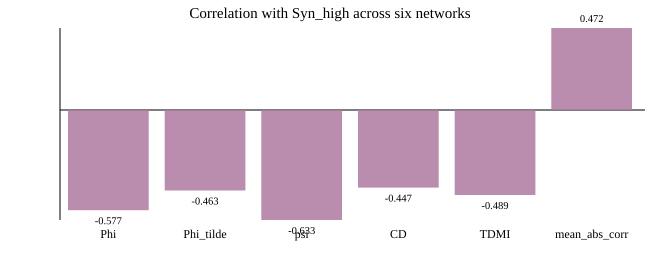

{'Syn_high': ['B', 'C', 'D', 'A', 'E', 'F'],
 'Phi': ['F', 'B', 'C', 'E', 'D', 'A'],
 'Phi_tilde': ['F', 'B', 'C', 'D', 'E', 'A'],
 'psi': ['F', 'C', 'B', 'D', 'E', 'A'],
 'CD': ['F', 'C', 'B', 'D', 'E', 'A'],
 'TDMI': ['F', 'C', 'B', 'D', 'E', 'A']}

In [8]:
def pearson(values_a: dict[str, float], values_b: dict[str, float]) -> float:
    keys = list(values_a.keys())
    vector_a = np.array([values_a[key] for key in keys], dtype=float)
    vector_b = np.array([values_b[key] for key in keys], dtype=float)
    if np.allclose(vector_a, vector_a[0]) or np.allclose(vector_b, vector_b[0]):
        return 0.0
    return float(np.corrcoef(vector_a, vector_b)[0, 1])

syn_values = {k: v['syn_high'] for k, v in results.items()}
comparison_metrics = {
    'Phi': {k: v['phi'] for k, v in results.items()},
    'Phi_tilde': {k: v['phi_tilde'] for k, v in results.items()},
    'psi': {k: v['psi'] for k, v in results.items()},
    'CD': {k: v['causal_density'] for k, v in results.items()},
    'TDMI': {k: v['tdmi'] for k, v in results.items()},
    'mean_abs_corr': {k: v['mean_abs_corr'] for k, v in results.items()},
}

correlations = {name: pearson(syn_values, values) for name, values in comparison_metrics.items()}
render_bar_chart('Correlation with Syn_high across six networks', correlations, color='#AF7AA1')

metric_rankings = {
    name: [key for key, _ in sorted(results.items(), key=lambda item: item[1][field], reverse=True)]
    for name, field in [
        ('Syn_high', 'syn_high'),
        ('Phi', 'phi'),
        ('Phi_tilde', 'phi_tilde'),
        ('psi', 'psi'),
        ('CD', 'causal_density'),
        ('TDMI', 'tdmi'),
    ]
}
metric_rankings


## 结果总结

- 在把 EI 切换为均匀盒式干预之后，`Syn_high` 仍然与 Mediano 风格指标表现不同：它们彼此相关，但并不是对同一线性高斯动力学的可互换描述。
- `Phi` 和 `Phi_tilde` 关注的是在均匀二分下损失了什么，而 `Syn_high` 衡量的是有界干预 EI 中有多少部分无法通过单节点源贡献求和来恢复。
- 由于当前 EI 使用了有限支撑参数 `L`，它的绝对大小比基于划分的比较指标更依赖具体假设。实际中，排序和对比模式往往比 `EI_full` 的原始偏移量更稳健。
- `CD` 的行为更像是分布式的成对传递，而不是最高阶的联合增益，因此它与 `Syn_high` 的一致性应被理解为经验上的，而不是定义上的。


## 构造的大协同线性高斯示例

上面的基准网络大多是分布式且近似可加的，因此它们的最高阶 `Syn_high` 都比较有限。为了说明当前的有界干预公式在线性高斯情形下依然可能取得较大数值，我们现在构造一个刻意汇聚的机制：

- 8 个源变量全部只投影到 2 个下一时刻目标上；
- 这两个读出目标共享相同的源模式；
- 内部噪声较小。

这正是一种会削弱单源 EI、却增强联合 EI 的几何结构，因此残差项 `Syn_high = EI_full - UnBudget` 会变大。


In [9]:
def build_large_synergy_example(n_nodes: int = 8, gain: float = 0.6, noise_std: float = 0.3) -> tuple[np.ndarray, np.ndarray]:
    coupling = np.zeros((n_nodes, n_nodes), dtype=float)
    coupling[0, :] = gain / np.sqrt(n_nodes)
    coupling[1, :] = gain / np.sqrt(n_nodes)
    noise_covariance = (noise_std**2) * np.eye(n_nodes)
    return coupling, noise_covariance

large_syn_coupling, large_syn_noise = build_large_synergy_example()
large_syn_state_covariance = solve_stationary_covariance(large_syn_coupling, large_syn_noise)
large_syn_summary = linear_gaussian_uniform_box_ei_decomposition(
    large_syn_coupling,
    large_syn_noise,
    box_size=UNIFORM_BOX_SIZE,
    log_base=np.e,
)
large_syn_summary


{'ei_full': 10.665213086313543,
 'ei_singles': [-1.1539437501167216,
  -1.1539437501167216,
  -1.1539437501167216,
  -1.1539437501167216,
  -1.1539437501167216,
  -1.1539437501167216,
  -1.1539437501167216,
  -1.1539437501167216],
 'un_budget': -9.231550000933773,
 'syn_high': 19.896763087247315,
 'rho_high': 1.8655757673309348}

In [10]:
if HTML is not None:
    rows = [
        '<tr><th>Quantity</th><th>Value</th></tr>',
        f"<tr><td>L</td><td>{UNIFORM_BOX_SIZE:.3f}</td></tr>",
        f"<tr><td>EI_full</td><td>{large_syn_summary['ei_full']:.3f}</td></tr>",
        f"<tr><td>UnBudget</td><td>{large_syn_summary['un_budget']:.3f}</td></tr>",
        f"<tr><td>Syn_high</td><td>{large_syn_summary['syn_high']:.3f}</td></tr>",
        f"<tr><td>rho_high</td><td>{large_syn_summary['rho_high']:.3f}</td></tr>",
    ]
    display(HTML("<table style='border-collapse:collapse' border='1'>" + ''.join(rows) + '</table>'))
else:
    print(large_syn_summary)


Quantity,Value
L,13.765
EI_full,10.665
UnBudget,-9.232
Syn_high,19.897
rho_high,1.866


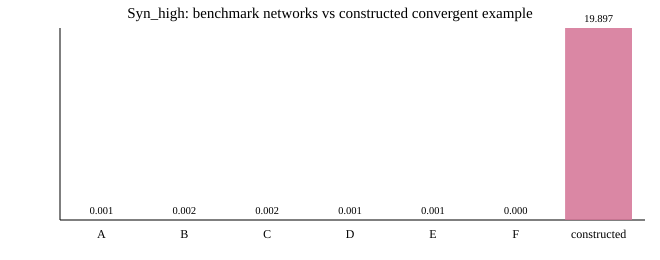

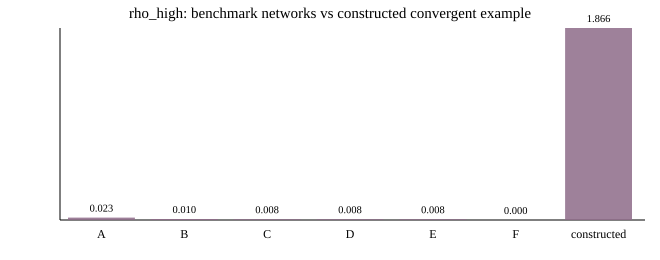

In [11]:
comparison = {k: v['syn_high'] for k, v in results.items()}
comparison['constructed'] = large_syn_summary['syn_high']
render_bar_chart('Syn_high: benchmark networks vs constructed convergent example', comparison, color='#D37295')

comparison_rho = {k: v['rho_high'] for k, v in results.items()}
comparison_rho['constructed'] = large_syn_summary['rho_high']
render_bar_chart('rho_high: benchmark networks vs constructed convergent example', comparison_rho, color='#8E6C8A')


### 为什么这个例子有效

在这个构造中，当我们隔离单个源时，另外七个源会表现为有效噪声，因此每个单独源都只能解释两个共享读出目标中的很小一部分。但把八个源联合起来看时，它们会沿着相同的低维输出方向进行相干贡献。在均匀盒近似下，这会产生远大于单源项求和的有界干预 `EI_full`，因此得到较大的正 `Syn_high`。


## 二维极小系统：低协同 vs 高协同

上面的 8 节点构造虽然能清楚地产生很大的 `Syn_high`，但直观上还是偏复杂。为了把几何机制压缩到最小，我们下面只看 2 个源、2 个目标的线性系统，并且只关注机制本身：雅可比矩阵 `A` 与噪声协方差 `Σ`。
\[
\Sigma = 0.2^2 I = \mathrm{diag}(0.04,\ 0.04).
\]
这里不再把这节解释成稳态对照实验，也不要求满足任何平稳协方差条件；我们只是在同一个噪声背景下，对比不同 `A` 的几何结构会怎样改变 `EI_full / UnBudget / Syn_high / rho_high`。均匀盒干预宽度固定为 `L = 3.5`。

我们首先对比两个最小系统：

- Diag：`A_diag = [[0.8, 0.0], [0.0, 0.8]]`。两个源各自驱动一个不同的目标方向。
- Cross：`A_cross = [[0.8, 0.8], [0.0, 0.8]]`。它与 `Diag` 具有完全相同的对角线项，只是额外打开了一个非对角耦合 `x2 -> x1`，使两个源在输出空间里不再完全分离。

在这个设定里，我们只保留这两个最小系统，专门回答一个问题：在相同噪声协方差 `Σ` 下，仅仅增加一个非对角耦合项，`Syn_high` 会怎样变化？

In [12]:
MINI_BOX_SIZE = 3.5
MINI_NODE_LABELS = ['x1', 'x2']
MINI_NOISE_COVARIANCE = (0.2**2) * np.eye(2)

mini_systems = {
    'Diag': {
        'label': 'Diag：纯对角耦合',
        'coupling': np.array([[0.8, 0.0], [0.0, 0.8]], dtype=float),
    },
    'Cross': {
        'label': 'Cross：在相同对角线外额外加入 x2 -> x1',
        'coupling': np.array([[0.8, 0.8], [0.0, 0.8]], dtype=float),
    },
}

mini_results = {}
for name, spec in mini_systems.items():
    coupling = spec['coupling']
    summary = linear_gaussian_uniform_box_ei_decomposition(
        coupling,
        MINI_NOISE_COVARIANCE,
        box_size=MINI_BOX_SIZE,
        log_base=np.e,
    )
    mini_results[name] = {
        'label': spec['label'],
        'coupling': coupling,
        'noise_covariance': MINI_NOISE_COVARIANCE.copy(),
        **summary,
    }

mini_results

{'Diag': {'label': 'Diag：纯对角耦合',
  'coupling': array([[0.8, 0. ],
         [0. , 0.8]]),
  'noise_covariance': array([[0.04, 0.  ],
         [0.  , 0.04]]),
  'ei_full': 2.440237592821172,
  'ei_singles': [1.220118796410586, 1.220118796410586],
  'un_budget': 2.440237592821172,
  'syn_high': 0.0,
  'rho_high': 0.0},
 'Cross': {'label': 'Cross：在相同对角线外额外加入 x2 -> x1',
  'coupling': array([[0.8, 0.8],
         [0. , 0.8]]),
  'noise_covariance': array([[0.04, 0.  ],
         [0.  , 0.04]]),
  'ei_full': 2.4402375928211724,
  'ei_singles': [0.8881803972806706, 1.2481635297361078],
  'un_budget': 2.136343927016778,
  'syn_high': 0.30389366580439425,
  'rho_high': 0.12453445791442835}}

In [13]:
if HTML is not None:
    rows = [
        '<tr><th>System</th><th>机制结构</th><th>总 EI (EI_full)</th><th>最高阶协同 (Syn_high)</th></tr>'
    ]
    for name in ['Diag', 'Cross']:
        row = mini_results[name]
        rows.append(
            '<tr>'
            f'<td>{name}</td>'
            f"<td>{html.escape(row['label'])}</td>"
            f"<td>{row['ei_full']:.3f}</td>"
            f"<td>{row['syn_high']:.3f}</td>"
            '</tr>'
        )
    display(HTML(
        f"<p><strong>二维示例统一设定：</strong> L = {MINI_BOX_SIZE:.1f}, Σ = diag(0.04, 0.04)</p>"
        + "<table style='border-collapse:collapse;text-align:center' border='1'>"
        + ''.join(rows)
        + '</table>'
    ))
else:
    print({name: {'ei_full': row['ei_full'], 'syn_high': row['syn_high']} for name, row in mini_results.items()})


System,机制结构,总 EI (EI_full),最高阶协同 (Syn_high)
Diag,Diag：纯对角耦合,2.440,0.000
Cross,Cross：在相同对角线外额外加入 x2 -> x1,2.440,0.304


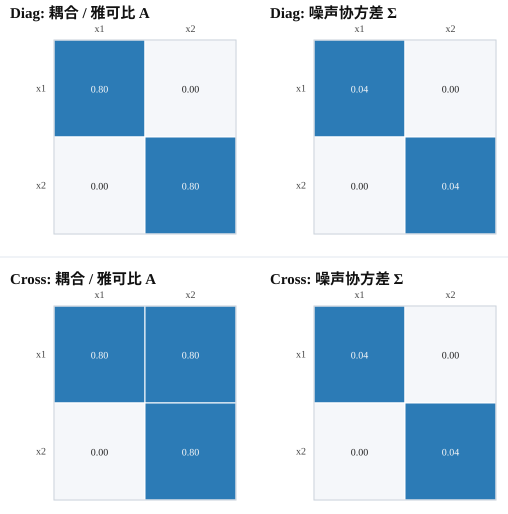

In [14]:
PANEL_WIDTH = 248
PANEL_HEIGHT = 248
PANEL_GAP = 12
ROW_GAP = 18


def _extract_svg_canvas(svg: str) -> tuple[float, float, str]:
    width_start = svg.index("width='") + len("width='")
    width_end = svg.index("'", width_start)
    height_start = svg.index("height='") + len("height='")
    height_end = svg.index("'", height_start)
    inner_start = svg.index('>') + 1
    inner_end = svg.rindex('</svg>')
    return (
        float(svg[width_start:width_end]),
        float(svg[height_start:height_end]),
        svg[inner_start:inner_end],
    )



def render_two_node_comparison_svg(order: list[str]) -> str:
    row_svgs = []
    for name in order:
        row = mini_results[name]
        row_svgs.append([
            render_matrix_heatmap_svg(
                f'{name}: 耦合 / 雅可比 A',
                row['coupling'],
                row_labels=MINI_NODE_LABELS,
                col_labels=MINI_NODE_LABELS,
                width=PANEL_WIDTH,
                height=PANEL_HEIGHT,
                decimals=2,
            ),
            render_matrix_heatmap_svg(
                f'{name}: 噪声协方差 Σ',
                row['noise_covariance'],
                row_labels=MINI_NODE_LABELS,
                col_labels=MINI_NODE_LABELS,
                width=PANEL_WIDTH,
                height=PANEL_HEIGHT,
                decimals=2,
            ),
        ])

    total_width = 2 * PANEL_WIDTH + PANEL_GAP
    total_height = len(row_svgs) * PANEL_HEIGHT + (len(row_svgs) - 1) * ROW_GAP
    pieces = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{total_width}' height='{total_height}' viewBox='0 0 {total_width} {total_height}'>",
        f"<rect x='0' y='0' width='{total_width}' height='{total_height}' fill='white'/>",
    ]

    y_offset = 0.0
    for row_index, svgs in enumerate(row_svgs):
        x_offset = 0.0
        for svg in svgs:
            width, _, inner = _extract_svg_canvas(svg)
            pieces.append(f"<g transform='translate({x_offset:.1f},{y_offset:.1f})'>{inner}</g>")
            x_offset += width + PANEL_GAP
        if row_index < len(row_svgs) - 1:
            separator_y = y_offset + PANEL_HEIGHT + ROW_GAP / 2.0
            pieces.append(
                f"<line x1='0' y1='{separator_y:.1f}' x2='{total_width:.1f}' y2='{separator_y:.1f}' stroke='#e2e8f0' stroke-width='1'/>"
            )
        y_offset += PANEL_HEIGHT + ROW_GAP

    pieces.append('</svg>')
    return ''.join(pieces)


mini_two_node_svg = render_two_node_comparison_svg(['Diag', 'Cross'])
if SVG is not None:
    display(SVG(mini_two_node_svg))
else:
    print(mini_two_node_svg)


### 如何理解这两个二维例子

- `Diag` 的 `Syn_high = 0`：两个源在输出空间里仍然完全分开，每个源都各自对应一个独立目标方向，所以整体 EI 基本就是两个单源 EI 的直接相加。
- `Cross` 与 `Diag` 具有完全相同的对角线项，因此每个变量自身的直接保留强度没有变化；它只是额外加入了一个非对角耦合 `x2 -> x1`。正是这个额外的交叉耦合，让 `x2` 不再只作用于自己的独立方向，而是开始与 `x1` 在输出 `x1(t+1)` 上发生重叠，从而产生正的 `Syn_high`。
- 在这个特定构造里，`Diag` 与 `Cross` 的总 EI 几乎相同，但 `Cross` 的最高阶协同明显更高。因此这个最小例子把“总量相近”和“协同结构不同”分得更干净：差异主要来自是否存在跨变量的耦合，而不是来自对角线强度本身。

所以，这个版本的二维对照更适合强调一个更精细的机制结论：即使固定每个变量自己的对角线作用强度不变，只要额外打开非对角耦合，系统就可能从近乎可加的机制变成具有明显联合增益的机制。

## 固定 A，只改变噪声相关性

上一个二维对照回答的是“在相同噪声协方差 `Σ` 下，只改雅可比矩阵 `A`，协同会怎样变化”。下面我们反过来固定 `A`，只改变噪声协方差的非对角项，看看相关噪声本身会怎样影响 `EI_full` 与 `Syn_high`。

我们令
\[
\Sigma(\rho) = 0.04
\begin{bmatrix}
1 & \rho \\
\rho & 1
\end{bmatrix}, \qquad \rho \in \{-0.8, -0.4, 0, 0.4, 0.8\}.
\]
这样对角线方差始终固定为 `0.04`，只有相关系数 `ρ` 在变化，因此这个实验专门隔离“非对角噪声相关性”的作用。

这里仍然并排比较两种机制：

- `Diag`：`A_diag = [[0.8, 0.0], [0.0, 0.8]]`
- `Cross`：`A_cross = [[0.8, 0.8], [0.0, 0.8]]`

要回答的问题是：当 `A` 完全不变、只让 `Σ` 从对角阵变成相关噪声时，总 EI 与协同会如何变化？以及，这种变化会不会受到非对角耦合方向与噪声相关方向是否对齐的影响？

In [15]:
NOISE_SCAN_RHOS = np.array([-0.8, -0.4, 0.0, 0.4, 0.8], dtype=float)
NOISE_SCAN_REPRESENTATIVE_RHOS = [-0.8, 0.0, 0.8]
NOISE_SCAN_VARIANCE = 0.04

noise_scan_systems = {
    'Diag': {
        'label': 'Diag：固定对角 A',
        'coupling': np.array([[0.8, 0.0], [0.0, 0.8]], dtype=float),
    },
    'Cross': {
        'label': 'Cross：固定上三角 A，额外加入 x2 -> x1',
        'coupling': np.array([[0.8, 0.8], [0.0, 0.8]], dtype=float),
    },
}


def build_correlated_noise_covariance(rho: float, variance: float = NOISE_SCAN_VARIANCE) -> np.ndarray:
    return variance * np.array([[1.0, rho], [rho, 1.0]], dtype=float)


noise_scan_results = {}
for name, spec in noise_scan_systems.items():
    coupling = spec['coupling']
    series = []
    for rho in NOISE_SCAN_RHOS:
        covariance = build_correlated_noise_covariance(float(rho))
        summary = linear_gaussian_uniform_box_ei_decomposition(
            coupling,
            covariance,
            box_size=MINI_BOX_SIZE,
            log_base=np.e,
        )
        series.append({
            'rho': float(rho),
            'noise_covariance': covariance,
            'ei_full': float(summary['ei_full']),
            'syn_high': float(summary['syn_high']),
        })
    noise_scan_results[name] = {
        'label': spec['label'],
        'coupling': coupling,
        'series': series,
    }

noise_scan_results

{'Diag': {'label': 'Diag：固定对角 A',
  'coupling': array([[0.8, 0. ],
         [0. , 0.8]]),
  'series': [{'rho': -0.8,
    'noise_covariance': array([[ 0.04 , -0.032],
           [-0.032,  0.04 ]]),
    'ei_full': 2.9510632165871624,
    'syn_high': 0.47320363197640614},
   {'rho': -0.4,
    'noise_covariance': array([[ 0.04 , -0.016],
           [-0.016,  0.04 ]]),
    'ei_full': 2.5274142863935607,
    'syn_high': 0.07790305678705955},
   {'rho': 0.0,
    'noise_covariance': array([[0.04, 0.  ],
           [0.  , 0.04]]),
    'ei_full': 2.440237592821172,
    'syn_high': 0.0},
   {'rho': 0.4,
    'noise_covariance': array([[0.04 , 0.016],
           [0.016, 0.04 ]]),
    'ei_full': 2.5274142863935607,
    'syn_high': 0.07790305678705955},
   {'rho': 0.8,
    'noise_covariance': array([[0.04 , 0.032],
           [0.032, 0.04 ]]),
    'ei_full': 2.9510632165871624,
    'syn_high': 0.47320363197640614}]},
 'Cross': {'label': 'Cross：固定上三角 A，额外加入 x2 -> x1',
  'coupling': array([[0.8, 0.8],


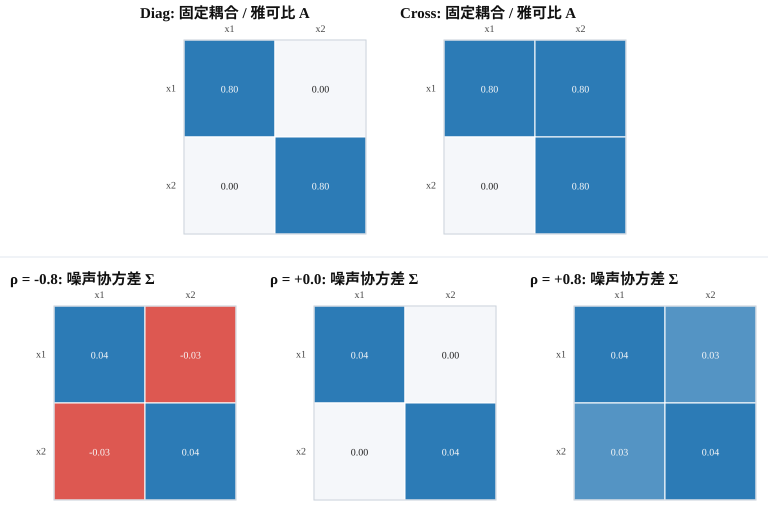

In [16]:
FIXED_A_PANEL_WIDTH = 248
FIXED_A_PANEL_HEIGHT = 248
FIXED_A_PANEL_GAP = 12
FIXED_A_ROW_GAP = 18


def render_fixed_a_noise_scan_layout_svg() -> str:
    top_row = [
        render_matrix_heatmap_svg(
            'Diag: 固定耦合 / 雅可比 A',
            noise_scan_results['Diag']['coupling'],
            row_labels=MINI_NODE_LABELS,
            col_labels=MINI_NODE_LABELS,
            width=FIXED_A_PANEL_WIDTH,
            height=FIXED_A_PANEL_HEIGHT,
            decimals=2,
        ),
        render_matrix_heatmap_svg(
            'Cross: 固定耦合 / 雅可比 A',
            noise_scan_results['Cross']['coupling'],
            row_labels=MINI_NODE_LABELS,
            col_labels=MINI_NODE_LABELS,
            width=FIXED_A_PANEL_WIDTH,
            height=FIXED_A_PANEL_HEIGHT,
            decimals=2,
        ),
    ]
    bottom_row = [
        render_matrix_heatmap_svg(
            f'ρ = {rho:+.1f}: 噪声协方差 Σ',
            build_correlated_noise_covariance(rho),
            row_labels=MINI_NODE_LABELS,
            col_labels=MINI_NODE_LABELS,
            width=FIXED_A_PANEL_WIDTH,
            height=FIXED_A_PANEL_HEIGHT,
            decimals=2,
        )
        for rho in NOISE_SCAN_REPRESENTATIVE_RHOS
    ]

    rows = [top_row, bottom_row]
    row_widths = []
    row_heights = []
    row_contents = []
    for svgs in rows:
        parsed = [_extract_svg_canvas(svg) for svg in svgs]
        row_contents.append(parsed)
        row_widths.append(sum(width for width, _, _ in parsed) + FIXED_A_PANEL_GAP * (len(parsed) - 1))
        row_heights.append(max(height for _, height, _ in parsed))

    total_width = max(row_widths)
    total_height = sum(row_heights) + FIXED_A_ROW_GAP * (len(rows) - 1)
    pieces = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{total_width}' height='{total_height}' viewBox='0 0 {total_width} {total_height}'>",
        f"<rect x='0' y='0' width='{total_width}' height='{total_height}' fill='white'/>",
    ]

    y_offset = 0.0
    for row_index, parsed in enumerate(row_contents):
        row_width = row_widths[row_index]
        x_offset = (total_width - row_width) / 2.0
        for width, _, inner in parsed:
            pieces.append(f"<g transform='translate({x_offset:.1f},{y_offset:.1f})'>{inner}</g>")
            x_offset += width + FIXED_A_PANEL_GAP
        y_offset += row_heights[row_index]
        if row_index < len(row_contents) - 1:
            separator_y = y_offset + FIXED_A_ROW_GAP / 2.0
            pieces.append(
                f"<line x1='0' y1='{separator_y:.1f}' x2='{total_width:.1f}' y2='{separator_y:.1f}' stroke='#e2e8f0' stroke-width='1'/>"
            )
            y_offset += FIXED_A_ROW_GAP

    pieces.append('</svg>')
    return ''.join(pieces)


fixed_a_noise_layout_svg = render_fixed_a_noise_scan_layout_svg()
if SVG is not None:
    display(SVG(fixed_a_noise_layout_svg))
else:
    print(fixed_a_noise_layout_svg)

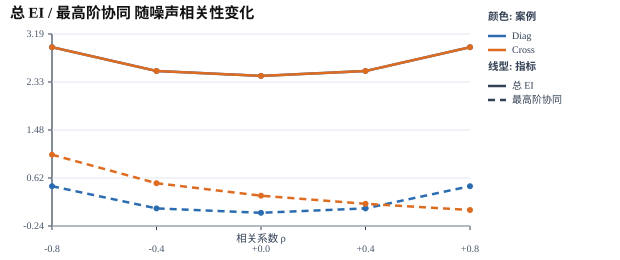

In [17]:
LINE_CHART_WIDTH = 620
LINE_CHART_HEIGHT = 260
LINE_COLORS = {'Diag': '#2b6cb0', 'Cross': '#dd6b20'}
LINE_DASHES = {'ei_full': '', 'syn_high': '7,5'}
LINE_LABELS = {'ei_full': '总 EI', 'syn_high': '最高阶协同'}


def _nice_tick_values(vmin: float, vmax: float, n_ticks: int = 5) -> list[float]:
    if math.isclose(vmin, vmax):
        return [vmin]
    return np.linspace(vmin, vmax, n_ticks).tolist()



def render_combined_noise_scan_curve_svg() -> str:
    left_margin = 52.0
    right_margin = 150.0
    top_margin = 34.0
    bottom_margin = 34.0
    plot_width = LINE_CHART_WIDTH - left_margin - right_margin
    plot_height = LINE_CHART_HEIGHT - top_margin - bottom_margin

    x_values = NOISE_SCAN_RHOS.astype(float)
    y_values = [
        point[metric_key]
        for result in noise_scan_results.values()
        for point in result['series']
        for metric_key in ['ei_full', 'syn_high']
    ]
    y_min = float(min(y_values))
    y_max = float(max(y_values))
    y_pad = 0.08 * max(y_max - y_min, 0.1)
    y_min -= y_pad
    y_max += y_pad

    def scale_x(value: float) -> float:
        return left_margin + (value - x_values.min()) / (x_values.max() - x_values.min()) * plot_width

    def scale_y(value: float) -> float:
        return top_margin + (y_max - value) / (y_max - y_min) * plot_height

    pieces = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{LINE_CHART_WIDTH}' height='{LINE_CHART_HEIGHT}'>",
        f"<rect x='0' y='0' width='{LINE_CHART_WIDTH}' height='{LINE_CHART_HEIGHT}' fill='white'/>",
        f"<text x='10' y='18' font-size='15' font-weight='700' fill='#111'>总 EI / 最高阶协同 随噪声相关性变化</text>",
        f"<line x1='{left_margin:.1f}' y1='{top_margin + plot_height:.1f}' x2='{left_margin + plot_width:.1f}' y2='{top_margin + plot_height:.1f}' stroke='#334155' stroke-width='1.2'/>",
        f"<line x1='{left_margin:.1f}' y1='{top_margin:.1f}' x2='{left_margin:.1f}' y2='{top_margin + plot_height:.1f}' stroke='#334155' stroke-width='1.2'/>",
    ]

    for rho in x_values:
        x = scale_x(float(rho))
        pieces.append(f"<line x1='{x:.1f}' y1='{top_margin + plot_height:.1f}' x2='{x:.1f}' y2='{top_margin + plot_height + 4:.1f}' stroke='#334155' stroke-width='1'/>")
        pieces.append(f"<text x='{x:.1f}' y='{LINE_CHART_HEIGHT - 8:.1f}' font-size='10' text-anchor='middle' fill='#475569'>{rho:+.1f}</text>")

    for tick in _nice_tick_values(y_min, y_max):
        y = scale_y(float(tick))
        pieces.append(f"<line x1='{left_margin - 4:.1f}' y1='{y:.1f}' x2='{left_margin:.1f}' y2='{y:.1f}' stroke='#334155' stroke-width='1'/>")
        pieces.append(f"<line x1='{left_margin:.1f}' y1='{y:.1f}' x2='{left_margin + plot_width:.1f}' y2='{y:.1f}' stroke='#e2e8f0' stroke-width='1'/>")
        pieces.append(f"<text x='{left_margin - 8:.1f}' y='{y + 3:.1f}' font-size='10' text-anchor='end' fill='#475569'>{tick:.2f}</text>")

    legend_x = left_margin + plot_width + 18.0
    legend_y = 20
    pieces.append(f"<text x='{legend_x:.1f}' y='{legend_y:.1f}' font-size='10.5' font-weight='700' fill='#334155'>颜色: 案例</text>")
    for index, name in enumerate(['Diag', 'Cross']):
        color = LINE_COLORS[name]
        y = legend_y + 16 + index * 14
        pieces.append(f"<line x1='{legend_x:.1f}' y1='{y:.1f}' x2='{legend_x + 18:.1f}' y2='{y:.1f}' stroke='{color}' stroke-width='2.5'/>")
        pieces.append(f"<text x='{legend_x + 24:.1f}' y='{y + 3:.1f}' font-size='10' fill='#334155'>{name}</text>")

    style_legend_x = legend_x
    style_legend_y = legend_y + 50
    pieces.append(f"<text x='{style_legend_x:.1f}' y='{style_legend_y:.1f}' font-size='10.5' font-weight='700' fill='#334155'>线型: 指标</text>")
    for index, metric_key in enumerate(['ei_full', 'syn_high']):
        y = style_legend_y + 16 + index * 14
        dash = LINE_DASHES[metric_key]
        dash_attr = f" stroke-dasharray='{dash}'" if dash else ''
        pieces.append(f"<line x1='{style_legend_x:.1f}' y1='{y:.1f}' x2='{style_legend_x + 18:.1f}' y2='{y:.1f}' stroke='#334155' stroke-width='2.5'{dash_attr}/>")
        pieces.append(f"<text x='{style_legend_x + 24:.1f}' y='{y + 3:.1f}' font-size='10' fill='#334155'>{LINE_LABELS[metric_key]}</text>")

    for name in ['Diag', 'Cross']:
        color = LINE_COLORS[name]
        for metric_key in ['ei_full', 'syn_high']:
            dash = LINE_DASHES[metric_key]
            dash_attr = f" stroke-dasharray='{dash}'" if dash else ''
            points = []
            for point in noise_scan_results[name]['series']:
                x = scale_x(point['rho'])
                y = scale_y(point[metric_key])
                points.append(f"{x:.1f},{y:.1f}")
            pieces.append(f"<polyline fill='none' stroke='{color}' stroke-width='2.5'{dash_attr} points='{' '.join(points)}'/>")
            for point in noise_scan_results[name]['series']:
                x = scale_x(point['rho'])
                y = scale_y(point[metric_key])
                pieces.append(f"<circle cx='{x:.1f}' cy='{y:.1f}' r='3.0' fill='{color}'/>")

    pieces.append(f"<text x='{left_margin + plot_width / 2.0:.1f}' y='{LINE_CHART_HEIGHT - 18:.1f}' font-size='10.5' text-anchor='middle' fill='#334155'>相关系数 ρ</text>")
    pieces.append('</svg>')
    return ''.join(pieces)


noise_scan_curves_svg = render_combined_noise_scan_curve_svg()
if SVG is not None:
    display(SVG(noise_scan_curves_svg))
else:
    print(noise_scan_curves_svg)


In [18]:
if HTML is not None:
    rows = [
        '<tr><th>System</th><th>ρ</th><th>Σ 的非对角项</th><th>总 EI (EI_full)</th><th>最高阶协同 (Syn_high)</th></tr>'
    ]
    for name in ['Diag', 'Cross']:
        for point in noise_scan_results[name]['series']:
            off_diag = point['noise_covariance'][0, 1]
            rows.append(
                '<tr>'
                f'<td>{name}</td>'
                f"<td>{point['rho']:+.1f}</td>"
                f"<td>{off_diag:+.3f}</td>"
                f"<td>{point['ei_full']:.3f}</td>"
                f"<td>{point['syn_high']:.3f}</td>"
                '</tr>'
            )
    display(HTML(
        "<p><strong>固定 A、扫描相关噪声：</strong> 对角线方差恒为 0.04，只改变非对角相关项。</p>"
        + "<table style='border-collapse:collapse;text-align:center' border='1'>"
        + ''.join(rows)
        + '</table>'
    ))
else:
    print(noise_scan_results)

System,ρ,Σ 的非对角项,总 EI (EI_full),最高阶协同 (Syn_high)
Diag,-0.8,-0.032,2.951,0.473
Diag,-0.4,-0.016,2.527,0.078
Diag,+0.0,+0.000,2.440,0.000
Diag,+0.4,+0.016,2.527,0.078
Diag,+0.8,+0.032,2.951,0.473
Cross,-0.8,-0.032,2.951,1.036
Cross,-0.4,-0.016,2.527,0.527
Cross,+0.0,+0.000,2.440,0.304
Cross,+0.4,+0.016,2.527,0.159
Cross,+0.8,+0.032,2.951,0.049


### 如何理解固定 A、只改变噪声相关性的结果

- 对 `Diag` 而言，`A` 仍是对角的，`ρ = 0` 时没有协同；随着 `|ρ|` 增大，相关噪声会把一部分信息压到联合方向里，因此 `Syn_high` 从 `0` 抬升到正值。
- 对新的 `Cross` 而言，协同在 `ρ = 0` 时已经是正的，因为即使对角线项与 `Diag` 完全一样，额外的非对角耦合 `x2 -> x1` 也已经让两个源在输出空间里发生重叠。
- 这个版本下，`Cross` 对 `ρ` 不再呈现正负完全对称的响应：当 `ρ < 0` 时，相关噪声会进一步放大这条交叉耦合带来的联合增益；而当 `ρ > 0` 时，协同仍为正，但会被削弱。这说明噪声相关结构的作用，不只取决于强度 `|ρ|`，也取决于它与机制矩阵中非对角耦合方向之间是对齐还是抵消。
- 另一个值得注意的点是：在这个构造里，`Diag` 与 `Cross` 的总 EI 在 `ρ = 0` 时几乎相同，因此曲线差异主要反映的是协同结构而不是总体信号强度差异。

因此，这个实验现在更清楚地分离了两种来源：一类是 `A` 的非对角耦合带来的基础协同，另一类是 `Σ` 的相关结构对这份协同的进一步放大或削弱。

## 耦合 / 雅可比与平稳协方差模式

对于这里研究的线性高斯 AR(1) 系统，系统耦合矩阵与雅可比矩阵是一致的：在 \(X_{t+1} = A X_t + \varepsilon_t\) 中有 \(J = A\)。因此，下方各面板对每个系统都展示了全局耦合/雅可比矩阵 \(A\) 以及由此得到的平稳协方差矩阵 \(\Sigma_X\)。\(A\) 的行对应下一时刻目标，列对应当前时刻源。


In [19]:
NODE_LABELS = [f'x{i + 1}' for i in range(N_NODES)]

def render_matrix_pair(name: str, label: str, coupling: np.ndarray, covariance: np.ndarray, syn_high: float) -> str:
    coupling_svg = render_matrix_heatmap_svg(
        f'{name}: coupling / Jacobian A',
        coupling,
        subtitle=f'{label}; Syn_high={syn_high:.3f}',
        row_labels=NODE_LABELS,
        col_labels=NODE_LABELS,
        width=312,
        height=312,
        decimals=2,
    )
    covariance_svg = render_matrix_heatmap_svg(
        f'{name}: stationary covariance Σ_X',
        covariance,
        subtitle='steady-state second-order structure',
        row_labels=NODE_LABELS,
        col_labels=NODE_LABELS,
        width=312,
        height=312,
        decimals=2,
    )
    return (
        "<div style='display:flex;flex-wrap:wrap;gap:10px;margin:0 0 18px 0;padding:10px 8px 14px 8px;border-bottom:1px solid #e2e8f0;'>"
        + coupling_svg
        + covariance_svg
        + "</div>"
    )

systems_for_display = []
for name in ['A', 'B', 'C', 'D', 'E', 'F']:
    row = results[name]
    systems_for_display.append((name, row['label'], row['coupling'], row['state_covariance'], row['syn_high']))
systems_for_display.append(('G', 'constructed convergent high-synergy example', large_syn_coupling, large_syn_state_covariance, large_syn_summary['syn_high']))

if HTML is not None:
    blocks = [render_matrix_pair(name, label, coupling, covariance, syn_high) for name, label, coupling, covariance, syn_high in systems_for_display]
    display(HTML(''.join(blocks)))
else:
    for entry in systems_for_display:
        print(entry[0], entry[1])


In [20]:
def top_k_target_energy_share(coupling: np.ndarray, k: int = 2) -> float:
    row_energy = np.sum(np.asarray(coupling, dtype=float) ** 2, axis=1)
    total = float(np.sum(row_energy))
    if total <= 1e-12:
        return 0.0
    strongest = np.sort(row_energy)[-min(k, len(row_energy)):].sum()
    return float(strongest / total)

def top_k_covariance_eigen_share(covariance: np.ndarray, k: int = 2) -> float:
    eigenvalues = np.sort(np.linalg.eigvalsh(np.asarray(covariance, dtype=float)))
    total = float(np.sum(eigenvalues))
    if total <= 1e-12:
        return 0.0
    strongest = eigenvalues[-min(k, len(eigenvalues)):].sum()
    return float(strongest / total)

diagnostics = {}
for name, row in results.items():
    diagnostics[name] = {
        'label': row['label'],
        'syn_high': row['syn_high'],
        'rho_high': row['rho_high'],
        'top2_target_share': top_k_target_energy_share(row['coupling']),
        'top2_cov_eig_share': top_k_covariance_eigen_share(row['state_covariance']),
    }
diagnostics['G'] = {
    'label': 'constructed convergent high-synergy example',
    'syn_high': large_syn_summary['syn_high'],
    'rho_high': large_syn_summary['rho_high'],
    'top2_target_share': top_k_target_energy_share(large_syn_coupling),
    'top2_cov_eig_share': top_k_covariance_eigen_share(large_syn_state_covariance),
}

if HTML is not None:
    rows = [
        '<tr><th>System</th><th>Description</th><th>Syn_high</th><th>rho_high</th><th>Top-2 target energy share in A</th><th>Top-2 eigenvalue share in Σ_X</th></tr>'
    ]
    for name in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
        row = diagnostics[name]
        rows.append(
            '<tr>'
            f'<td>{name}</td>'
            f"<td>{html.escape(row['label'])}</td>"
            f"<td>{row['syn_high']:.3f}</td>"
            f"<td>{row['rho_high']:.3f}</td>"
            f"<td>{row['top2_target_share']:.3f}</td>"
            f"<td>{row['top2_cov_eig_share']:.3f}</td>"
            '</tr>'
        )
    display(HTML("<table style='border-collapse:collapse' border='1'>" + ''.join(rows) + '</table>'))
else:
    print(diagnostics)


System,Description,Syn_high,rho_high,Top-2 target energy share in A,Top-2 eigenvalue share in Σ_X
A,fully connected,0.001,0.023,0.250,0.507
B,binary-like optimal,0.002,0.010,0.333,0.512
C,weighted-like optimal,0.002,0.008,0.376,0.514
D,bidirectional ring,0.001,0.008,0.250,0.547
E,small world,0.001,0.008,0.333,0.491
F,unidirectional ring,0.000,0.000,0.250,0.250
G,constructed convergent high-synergy example,19.897,1.866,1.000,0.324


### 如何解读这些矩阵

这些矩阵视图有助于解释，为什么当前的最高阶 `Syn_high` 在线性系统中有时很小，而在构造示例中会很大。

- 在 `F` 中，耦合/雅可比矩阵本质上接近置换矩阵：每个源都被路由到不同的下一时刻目标。机制虽然很强，但各自贡献在几何上分散在不同目标方向上，因此全系统的有界干预 EI 与单源 EI 之和非常接近，`Syn_high` 也接近于零。
- 在 `A` 中，耦合虽然稠密，但广泛分布在许多目标上。平稳协方差体现的是分布式依赖，而不是尖锐的低维瓶颈，因此在当前有限盒干预下，最高阶残差协同仍然较小。
- 在构造的 `G` 系统中，几乎所有耦合能量都集中在两个目标行上，因此协方差也相应地变得更低维。这正是这样一种情形：隔离单个源时，其余源会像有效噪声一样存在；而把所有源一起考虑时，则能恢复出一个相干的共享读出。
- 诊断表把这种直觉定量化了：当机制能量集中在少数目标上、同时平稳协方差也由少数共享模态主导时，更有可能观察到更高的 `Syn_high`。

因此，这个比较并不是说线性高斯系统不能产生协同，而是说明：在当前均匀盒干预下，当全局雅可比把许多输入自由度压缩到少数几个联合输出方向时，就会出现较大的协同。
